# Análisis Exploratorio de Datos para Mantenimiento Predictivo de Transformadores Eléctricos
1. *Proyecto*: Sistema de Mantenimiento Predictivo Basado en IA para Transformadores Eléctricos
2. *Equipo Objetivo:* Transformador Regulador WEG (Potencia 40MVA)
3. *Empresa:* ISI Mustang Bolivia SRL
4. *Tipo de Transformador:* Regulador de Tensión con OLTC

Análisis Exploratorio de Datos para Mantenimiento Predictivo de Transformadores Eléctricos
Proyecto: Sistema de Mantenimiento Predictivo Basado en IA para Transformadores Eléctricos
Equipo Objetivo: Transformador Regulador WEG (Potencia 40MVA)
Empresa: ISI Mustang Bolivia SRL
Tipo de Transformador: Regulador de Tensión con OLTC

El transformador bajo estudio es una unidad WEG de 40MVA con las siguientes características técnicas principales:

-Potencia Nominal: 40MVA
-Tensión Primaria: 23kV
-Tensión Secundaria: 220V (regulable)
-Tipo de Regulación: OLTC (On Load Tap Changer)
-Frecuencia Nominal: 50Hz
-Refrigeración: ONAN (aceite natural, aire natural)
-Rangos de Tap: Posiciones 1-17 (tap central en posición 9)

In [1]:
# Librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np
import polars as pl
from pathlib import Path
from typing import List, Dict, Optional
from deltalake import DeltaTable

# Instalar jinja2 si no está disponible (para usar pandas .style)
try:
    import jinja2
    print("jinja2 ya está instalado")
except ImportError:
    print(" Instalando jinja2...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jinja2"])
    import jinja2
    print("jinja2 instalado correctamente")

# Librerías para visualización
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Librerías para análisis estadístico
from scipy import stats
from scipy.stats import normaltest, shapiro, jarque_bera, anderson
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Librerías para análisis de series temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Librerías para detección de outliers
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM

# Configuraciones
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Todas las librerías han sido importadas correctamente")
print(f" Versión de pandas: {pd.__version__}")
print(f" Versión de numpy: {np.__version__}")
print(f" Versión de matplotlib: {matplotlib.__version__}")
print(f" Versión de jinja2: {jinja2.__version__}")


jinja2 ya está instalado
Todas las librerías han sido importadas correctamente
 Versión de pandas: 2.2.3
 Versión de numpy: 2.2.6
 Versión de matplotlib: 3.10.3
 Versión de jinja2: 3.1.6


# Carga e Inspección Inicial de Datos

### Importancia de la Inspección Inicial
La inspección inicial de datos constituye el primer paso fundamental en cualquier análisis exploratorio, especialmente crítico cuando se trata de datos operacionales de equipos industriales como transformadores eléctricos. Esta etapa permite establecer la base para todo el análisis posterior, identificando características estructurales, patrones temporales, y posibles problemas en la calidad de los datos que podrían afectar la validez de las conclusiones.

En el contexto de sistemas de monitoreo de transformadores, los datos provienen típicamente de sensores distribuidos que registran variables a diferentes frecuencias de muestreo. La sincronización temporal, la completitud de los registros, y la coherencia de los rangos de medición son aspectos críticos que deben evaluarse minuciosamente.

In [2]:
# ==================== CONFIG & PATHS (Bronze + Specs) ====================
from pathlib import Path
from deltalake import DeltaTable
import pandas as pd

# --- Helper to resolve repo root (walk up until 'data' is found) ---
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

# --- Paths (Delta Lake Bronze) ---
REPO_ROOT = find_repo_root()
BRONZE_TABLE = REPO_ROOT / "data" / "capa_bronze" / "readings_v1"

print(" *Repo root:", REPO_ROOT)
print(" *Bronze table path:", BRONZE_TABLE)

# --- Load Bronze & list available tags ---
if BRONZE_TABLE.exists():
    print(" Bronze path found")
    dt = DeltaTable(str(BRONZE_TABLE))
    try:
        # Fast path: read only 'tag' column
        tags_disponibles = (
            dt.to_pyarrow_table(columns=["tag"])
              .to_pandas()["tag"]
              .astype(str)
              .dropna()
              .unique()
              .tolist()
        )
    except Exception:
        # Fallback: read full, then reduce
        pdf = dt.to_pyarrow_table().to_pandas()
        tags_disponibles = (
            pd.Series(pdf.get("tag", []))
              .astype(str)
              .dropna()
              .unique()
              .tolist()
        )
    print(f" *Tags disponibles en Bronze: {len(tags_disponibles)}")
    if tags_disponibles[:10]:
        print("* Muestra:", tags_disponibles[:10], "...")
else:
    print(" Bronze path NOT found — verifica la ruta anterior antes de continuar")
    tags_disponibles = []

# ==================== TRANSFORMER SPECS ====================
# ( valores como referencia técnica para reglas/umbrales)
SPECS_TRANSFORMADOR = {
    "potencia_nominal_mva": 40,
    "tension_primaria_kv": 23,
    "tension_secundaria_v": 220,
    "frecuencia_hz": 50,
    "tipo_refrigeracion": "ONAN",
    "rango_tap": (1, 17),
    "tap_central": 9,
    "corriente_nominal_a": 1050,     # Aproximada para 40 MVA en 23 kV (lado AT).
    "temp_aceite_max_c": 65,
    "temp_punto_caliente_max_c": 110,
    "temp_ambiente_nominal_c": 40,
}

print(
    f" *Transformador: {SPECS_TRANSFORMADOR['potencia_nominal_mva']} MVA | "
    f"{SPECS_TRANSFORMADOR['tension_primaria_kv']} kV → {SPECS_TRANSFORMADOR['tension_secundaria_v']} V | "
    f"{SPECS_TRANSFORMADOR['tipo_refrigeracion']}"
)

# ==================== NORMAL OPERATING RANGES ====================
# (Usados para diagnóstico de EDA y clamps/validaciones en Silver/Gold)
RANGOS_NORMALES = {
    "temperatura_aceite": (20, 65),
    "temperatura_aceite_OLTC": (20, 60),
    "temperatura_ambiente": (10, 45),
    "temperatura_burbujeo": (60, 200),
    "temperatura_punto_caliente": (30, 110),
    "voltaje": (100, 150),            # Ajusta según tu base (V o kV). Aquí es un rango ilustrativo.
    "corriente_carga": (0, 1200),     # Con margen para sobrecarga temporal
    "potencia_aparente": (0, 50),     # MVA
    "tap_position": (1, 17),
}

print("  Configuración establecida para análisis y validaciones.")


# ==================== Validaciones rápidas ====================
if not tags_disponibles:
    print(" No hay tags disponibles en Bronze el notebook se detiene.")
else:
    faltantes = [t for t in RANGOS_NORMALES.keys() if t not in tags_disponibles]
    if faltantes:
        print(" Variables con rango definido pero ausentes en Bronze:", faltantes)
    else:
        print(" Todos los rangos definidos tienen presencia en Bronze .")


##grafica de series temporales
print("GRÁFICAS DE SERIES TEMPORALES POR VARIABLE")

 *Repo root: C:\Users\Asus TUF\Desktop\proy_ml
 *Bronze table path: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_bronze\readings_v1
 Bronze path found
 *Tags disponibles en Bronze: 91
* Muestra: ['ventilador_14_mcb', 'ventilador_13_mcb', 'ventilador_12_mcb', 'ventilador_11_mcb', 'ventilador_10_mcb', 'ventilador_9_mcb', 'ventilador_8_mcb', 'ventilador_7_mcb', 'ventilador_6_mcb', 'ventilador_5_mcb'] ...
 *Transformador: 40 MVA | 23 kV → 220 V | ONAN
  Configuración establecida para análisis y validaciones.
 Todos los rangos definidos tienen presencia en Bronze .
GRÁFICAS DE SERIES TEMPORALES POR VARIABLE


In [3]:
# Obtener el número total de filas en la tabla Delta
total_rows = dt.to_pyarrow_table().num_rows
print(f"Total de registros en readings_v1: {total_rows}")

Total de registros en readings_v1: 32853372


In [ ]:
# ==================== CARGA DESDE BRONZE (formato de salida detallado) ====================
from pathlib import Path
import numpy as np
import pandas as pd
from deltalake import DeltaTable

def cargar_tag_desde_bronze(tag: str, bronze_path: Path) -> pd.DataFrame | None:
    """
    Lee un 'tag' desde Bronze (Delta) y devuelve un DataFrame con:
      - 'timestamp' (UTC, limpio)
      - columna renombrada con el nombre del tag (a partir de value/value_text/value_bool)
    Imprime un resumen detallado al estilo solicitado.
    """
    try:
        if not bronze_path.exists():
            print(f"  Bronze path no existe: {bronze_path}")
            return None

        # Descubrir columnas disponibles en la tabla Delta (versiones varían)
        dt = DeltaTable(str(bronze_path))
        schema = dt.schema()
        try:
            schema_names = schema.names
        except Exception:
            try:
                schema_names = [f.name for f in getattr(schema, "fields", schema)]
            except Exception:
                schema_names = []

        # Columnas a intentar leer
        candidate_cols = [c for c in ["timestamp", "ts", "tag", "value", "value_text", "value_bool"] if c in schema_names]

        print(f"   Intentando cargar desde Delta: {bronze_path.resolve()}")
        # Intentar pushdown filter por tag (algunas versiones no soportan 'filters')
        if candidate_cols:
            try:
                pa = dt.to_pyarrow_table(columns=candidate_cols, filters=[("tag", "=", tag)])
            except TypeError:
                pa = dt.to_pyarrow_table(columns=candidate_cols)
        else:
            pa = dt.to_pyarrow_table()

        pdf = pa.to_pandas()

        # Filtrar por tag si no se pudo en el scan
        if "tag" in pdf.columns:
            pdf = pdf[pdf["tag"] == tag].copy()

        if pdf.empty:
            print(f"   Sin filas para tag='{tag}'")
            return None

        # Contador original
        registros_originales = len(pdf)
        print(f"   -Procesando {registros_originales:,} timestamps...")

        # Normalizar timestamp
        tscol = "timestamp" if "timestamp" in pdf.columns else ("ts" if "ts" in pdf.columns else None)
        if tscol:
            pdf[tscol] = pd.to_datetime(pdf[tscol], utc=True, errors="coerce")
            if tscol != "timestamp":
                pdf = pdf.rename(columns={tscol: "timestamp"})
        else:
            pdf["timestamp"] = pd.NaT

        # Limpieza robusta de timestamps
        timestamps_nulos = pdf["timestamp"].isna().sum()
        if timestamps_nulos > 0:
            porcentaje_problematicos = (timestamps_nulos / registros_originales) * 100
            pdf = pdf.dropna(subset=["timestamp"]).copy()
            print(f"   Eliminadas {timestamps_nulos:,} filas con timestamp inválido ({porcentaje_problematicos:.3f}%).")

        if pdf.empty:
            print(f"   No quedan datos válidos para tag='{tag}' tras limpiar timestamps.")
            return None

        # Unificar la columna de valor: prioridad value > value_text (num) > value_bool
        if "value" not in pdf.columns:
            pdf["value"] = np.nan

        if "value" in pdf.columns and pdf["value"].notna().sum() == 0:
            # Intentar parsear value_text a numérico si value es todo NaN
            if "value_text" in pdf.columns:
                maybe_num = pd.to_numeric(pdf["value_text"], errors="coerce")
                if maybe_num.notna().sum() > 0:
                    pdf["value"] = maybe_num

        if pdf["value"].notna().sum() == 0 and "value_bool" in pdf.columns:
            pdf["value"] = pdf["value_bool"].astype("Int64")

        # Renombrar value -> tag
        pdf = pdf[["timestamp", "value"]].rename(columns={"value": tag})
        pdf = pdf.sort_values("timestamp").reset_index(drop=True)

        # Estadística rápida (solo si es numérico)
        vals_num = pd.to_numeric(pdf[tag], errors="coerce")
        vmin = vals_num.min(skipna=True)
        vmax = vals_num.max(skipna=True)
        vmean = vals_num.mean(skipna=True)

        # Resumen con estilo solicitado
        fecha_ini = pdf["timestamp"].min()
        fecha_fin = pdf["timestamp"].max()
        print(
            f"   {len(pdf):,} registros | "
            f"Rango: {fecha_ini.strftime('%Y-%m-%d')} a {fecha_fin.strftime('%Y-%m-%d')}"
        )
        if pd.notna(vmin) and pd.notna(vmax) and pd.notna(vmean):
            print(f"   Valores: {vmin:.2f} a {vmax:.2f} | Promedio: {vmean:.2f}")

        return pdf

    except Exception as e:
        print(f"   Error al cargar tag='{tag}': {e}")
        return None


# ---------------------------------------------------------------------------
# Elegir los tags a cargar (puedes limitar a RANGOS_NORMALES si prefieres controlado)
# ---------------------------------------------------------------------------
tags_a_cargar = [t for t in RANGOS_NORMALES.keys() if t in tags_disponibles]
# tags_a_cargar = tags_disponibles  # todos los disponibles en Bronze

print(f"Tags a cargar: {len(tags_a_cargar)}")

# ---------------------------------------------------------------------------
# Cargar todos los tags con la función anterior + resumen tabular
# ---------------------------------------------------------------------------   
datos_por_tag: dict[str, pd.DataFrame] = {}
resumen_carga: list[dict] = []

print("\n Cargando tags desde Bronze con parseo robusto de timestamps…")
print("=" * 100)

for tag in tags_a_cargar:
    print(f"* Procesando: {tag}*")
    df_tag = cargar_tag_desde_bronze(tag, BRONZE_TABLE)

    if df_tag is None or df_tag.empty:
        print("-" * 100)
        continue

    datos_por_tag[tag] = df_tag

    # Resumen por tag
    vals_num = pd.to_numeric(df_tag[tag], errors="coerce")
    info = {
        "variable": tag,
        "registros": len(df_tag),
        "fecha_inicio": df_tag["timestamp"].min(),
        "fecha_fin": df_tag["timestamp"].max(),
        "duracion_dias": (df_tag["timestamp"].max() - df_tag["timestamp"].min()).days if len(df_tag) else 0,
        "valores_nulos": vals_num.isna().sum(),
        "valor_min": vals_num.min(skipna=True),
        "valor_max": vals_num.max(skipna=True),
        "valor_medio": vals_num.mean(skipna=True),
    }
    resumen_carga.append(info)
    print("-" * 100)

# DataFrame resumen
if resumen_carga:
    resumen_df = (
        pd.DataFrame(resumen_carga)
        .sort_values("variable")
        .reset_index(drop=True)
    )
    print("\n RESUMEN DE CARGA COMPLETADO")
    print(f" Tags cargados: {len(datos_por_tag)}/{len(tags_a_cargar)}")
    print(f" Total de registros: {resumen_df['registros'].sum():,}")
else:
    print("\n CARGA FALLIDA — revisa rutas/tags.")
    resumen_df = pd.DataFrame()


Tags a cargar: 9

 Cargando tags desde Bronze con parseo robusto de timestamps…
* Procesando: temperatura_aceite*
   Intentando cargar desde Delta: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_bronze\readings_v1
   -Procesando 13,442 timestamps...
   Eliminadas 11 filas con timestamp inválido (0.082%).
   13,431 registros | Rango: 2024-09-10 a 2025-08-27
   Valores: 0.00 a 67.00 | Promedio: 46.21
----------------------------------------------------------------------------------------------------
* Procesando: temperatura_aceite_OLTC*
   Intentando cargar desde Delta: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_bronze\readings_v1
   -Procesando 11,525 timestamps...
   Eliminadas 8 filas con timestamp inválido (0.069%).
   11,517 registros | Rango: 2024-09-10 a 2025-08-27
   Valores: 0.00 a 61.90 | Promedio: 41.99
----------------------------------------------------------------------------------------------------
* Procesando: temperatura_ambiente*
   Intentando cargar desde Delta: C:\Use

In [5]:
# ==================== VISUALIZACIÓN DEL RESUMEN (adaptado a Bronze/Delta) ============================

if len(resumen_df) > 0:
    # Campos derivados útiles
    resumen_df_view = resumen_df.copy()
    # % de nulos por variable (siempre relativo a registros de esa variable)
    resumen_df_view["pct_nulos_%"] = (resumen_df_view["valores_nulos"] / resumen_df_view["registros"] * 100).round(3)

    try:
        display(
            resumen_df_view.style
                .format({
                    'registros': '{:,}',
                    'duracion_dias': '{:.0f}',
                    'valores_nulos': '{:,}',
                    'valor_min': '{:.2f}',
                    'valor_max': '{:.2f}',
                    'valor_medio': '{:.2f}',
                    'pct_nulos_%': '{:.3f}'
                })
                .background_gradient(subset=['registros'], cmap='Blues')
                .background_gradient(subset=['valores_nulos', 'pct_nulos_%'], cmap='Reds')
                .set_caption("Resumen de tags (Bronze → parseo robusto)")
        )
    except Exception:
        print("Resumen de tags (Bronze → parseo robusto)")
        print("-" * 120)
        display(resumen_df_view)

    # ==================== Estadísticas generales ====================
    print("\nESTADÍSTICAS GENERALES")
    print("=" * 60)
    total_regs = int(resumen_df['registros'].sum())
    inicio_min = pd.to_datetime(resumen_df['fecha_inicio']).min()
    fin_max    = pd.to_datetime(resumen_df['fecha_fin']).max()

    print(f"1. Total de registros combinados: {total_regs:,}")
    print(f"2. Fecha de inicio más temprana: {inicio_min.strftime('%Y-%m-%d %H:%M:%S') if pd.notna(inicio_min) else 'N/A'}")
    print(f"3. Fecha de fin más reciente:     {fin_max.strftime('%Y-%m-%d %H:%M:%S') if pd.notna(fin_max) else 'N/A'}")
    print(f"4. Periodo total (máximo por variable): {resumen_df['duracion_dias'].max():.0f} días")
    print(f"5. Variables con datos faltantes: {(resumen_df['valores_nulos'] > 0).sum()}/{len(resumen_df)}")
    print(f"6. Promedio de registros/variable: {resumen_df['registros'].mean():,.0f}")
    print(f"Desv. estándar de registros:    {resumen_df['registros'].std():,.0f}")

else:
    print("No se pudieron cargar datos para mostrar el resumen")
    print("Verifique la tabla Delta (Bronze) especificada:")
    print(f"Ruta Bronze esperada: {Path(BRONZE_TABLE).resolve()}")

,variable,registros,fecha_inicio,fecha_fin,duracion_dias,valores_nulos,valor_min,valor_max,valor_medio,pct_nulos_%
0,corriente_carga,"5,200,027",2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,351,951,0.00,1735.92,704.65,0.018
1,potencia_aparente,"377,354",2024-09-10 04:00:00+00:00,2025-08-27 23:55:00+00:00,351,"3,221",0.00,61.94,31.00,0.854
2,tap_position,"7,150",2024-09-10 01:59:12.914001+00:00,2025-08-27 21:49:22.092010+00:00,351,923,0.00,17.00,9.28,12.909
3,temperatura_aceite,"13,431",2024-09-10 00:43:12.798004+00:00,2025-08-27 23:43:09.128005+00:00,351,923,0.00,67.00,46.21,6.872
4,temperatura_aceite_OLTC,"11,517",2024-09-10 01:28:12.970001+00:00,2025-08-27 23:03:08.862014+00:00,351,"1,019",0.00,61.90,41.99,8.848
5,temperatura_ambiente,"26,471",2024-09-10 00:13:12.533004+00:00,2025-08-27 23:03:09.445007+00:00,351,"1,017",0.00,41.00,26.44,3.842
6,temperatura_burbujeo,"15,185",2024-09-10 00:50:03.095016+00:00,2025-08-27 23:31:33.135009+00:00,351,936,0.00,194.11,170.72,6.164
7,temperatura_punto_caliente,"19,026",2024-09-10 00:25:02.939010+00:00,2025-08-27 23:36:33.173004+00:00,351,922,0.00,80.38,54.15,4.846
8,voltaje,"3,699,416",2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,351,896,0.00,146.93,130.17,0.024



ESTADÍSTICAS GENERALES
1. Total de registros combinados: 9,369,577
2. Fecha de inicio más temprana: 2024-09-10 00:00:02
3. Fecha de fin más reciente:     2025-08-27 23:59:57
4. Periodo total (máximo por variable): 351 días
5. Variables con datos faltantes: 9/9
6. Promedio de registros/variable: 1,041,064
Desv. estándar de registros:    1,972,171


In [ ]:
# ==================== ANÁLISIS DE FRECUENCIAS DE MUESTREO (adaptado) ====================
# Usa: datos_por_tag  ->  { '<variable>': DataFrame(['timestamp', '<variable>']) }

print("ANÁLISIS DE FRECUENCIAS DE MUESTREO")
print("=" * 70)

frecuencias_muestreo: dict[str, dict] = {}

if isinstance(datos_por_tag, dict) and len(datos_por_tag) > 0:
    for variable, df in datos_por_tag.items():
        # --- Defensive checks ---
        if df is None or df.empty or "timestamp" not in df.columns:
            continue

        # Ensure datetime, sort, and drop duplicates
        ts = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
        tmp = pd.DataFrame({"timestamp": ts}).dropna().sort_values("timestamp").drop_duplicates("timestamp")

        # Need at least 2 timestamps to compute diffs
        if len(tmp) < 2:
            frecuencias_muestreo[variable] = {
                "variable": variable,
                "intervalo_mediano_seg": np.nan,
                "intervalo_promedio_seg": np.nan,
                "intervalo_min_seg": np.nan,
                "intervalo_max_seg": np.nan,
                "desviacion_std_seg": np.nan,
                "freq_estimada_hz": np.nan
            }
            print(f"{variable:30} | Intervalo mediano:        N/D | Freq:      N/D")
            continue

        # Time deltas
        diferencias_tiempo = tmp["timestamp"].diff().dropna()

        # Convert Timedelta to seconds safely
        to_seconds = lambda s: s.dt.total_seconds() if hasattr(s, "dt") else pd.Series([], dtype=float)
        diffs_sec = to_seconds(diferencias_tiempo)

        # Guard if diffs_sec somehow empty
        if diffs_sec.empty:
            frecuencias_muestreo[variable] = {
                "variable": variable,
                "intervalo_mediano_seg": np.nan,
                "intervalo_promedio_seg": np.nan,
                "intervalo_min_seg": np.nan,
                "intervalo_max_seg": np.nan,
                "desviacion_std_seg": np.nan,
                "freq_estimada_hz": np.nan
            }
            print(f"{variable:30} | Intervalo mediano:        N/D | Freq:      N/D")
            continue

        med = float(diffs_sec.median())
        mean = float(diffs_sec.mean())
        minv = float(diffs_sec.min())
        maxv = float(diffs_sec.max())
        stdv = float(diffs_sec.std(ddof=1)) if len(diffs_sec) > 1 else 0.0
        freq = (1.0 / med) if med > 0 else np.nan

        freq_info = {
            "variable": variable,
            "intervalo_mediano_seg": med,
            "intervalo_promedio_seg": mean,
            "intervalo_min_seg": minv,
            "intervalo_max_seg": maxv,
            "desviacion_std_seg": stdv,
            "freq_estimada_hz": freq
        }
        frecuencias_muestreo[variable] = freq_info

        print(f"{variable:30} | Intervalo mediano: {med:8.2f}s | Freq: {freq:8.4f}Hz")

    # Crear DataFrame de frecuencias
    freq_df = pd.DataFrame(list(frecuencias_muestreo.values())).sort_values(
        ["freq_estimada_hz", "intervalo_mediano_seg"],
        ascending=[False, True]
    ).reset_index(drop=True)

    print("\n CLASIFICACIÓN POR FRECUENCIA DE MUESTREO")
    # Clasificación por frecuencia 

    alta_frecuencia  = freq_df.loc[freq_df["freq_estimada_hz"] > 0.1, "variable"].tolist()
    media_frecuencia = freq_df.loc[(freq_df["freq_estimada_hz"] <= 0.1) & (freq_df["freq_estimada_hz"] > 0.01), "variable"].tolist()
    baja_frecuencia  = freq_df.loc[freq_df["freq_estimada_hz"] <= 0.01, "variable"].tolist()
    print("-" * 50)

    print(f"*Alta frecuencia (>0.1 Hz): {alta_frecuencia}")
    print(f"*Media frecuencia (0.01–0.1 Hz): {media_frecuencia}")
    print(f"*Baja frecuencia (≤0.01 Hz): {baja_frecuencia}")

else:
    print("No se pueden analizar frecuencias de muestreo — no hay datos cargados en 'datos_por_tag'.")
    freq_df = pd.DataFrame()  # evitar errores posteriores


ANÁLISIS DE FRECUENCIAS DE MUESTREO
temperatura_aceite             | Intervalo mediano:  1500.20s | Freq:   0.0007Hz
temperatura_aceite_OLTC        | Intervalo mediano:  1666.70s | Freq:   0.0006Hz
temperatura_ambiente           | Intervalo mediano:   600.10s | Freq:   0.0017Hz
temperatura_burbujeo           | Intervalo mediano:  1200.17s | Freq:   0.0008Hz
temperatura_punto_caliente     | Intervalo mediano:   900.24s | Freq:   0.0011Hz
voltaje                        | Intervalo mediano:     5.04s | Freq:   0.1983Hz
corriente_carga                | Intervalo mediano:     5.03s | Freq:   0.1989Hz
potencia_aparente              | Intervalo mediano:    60.00s | Freq:   0.0167Hz
tap_position                   | Intervalo mediano:   375.63s | Freq:   0.0027Hz

 CLASIFICACIÓN POR FRECUENCIA DE MUESTREO
--------------------------------------------------
*Alta frecuencia (>0.1 Hz): ['corriente_carga', 'voltaje']
*Media frecuencia (0.01–0.1 Hz): ['potencia_aparente']
*Baja frecuencia (≤0.01 Hz)

Visualización de disponibilidad y frecuencia de muestreo


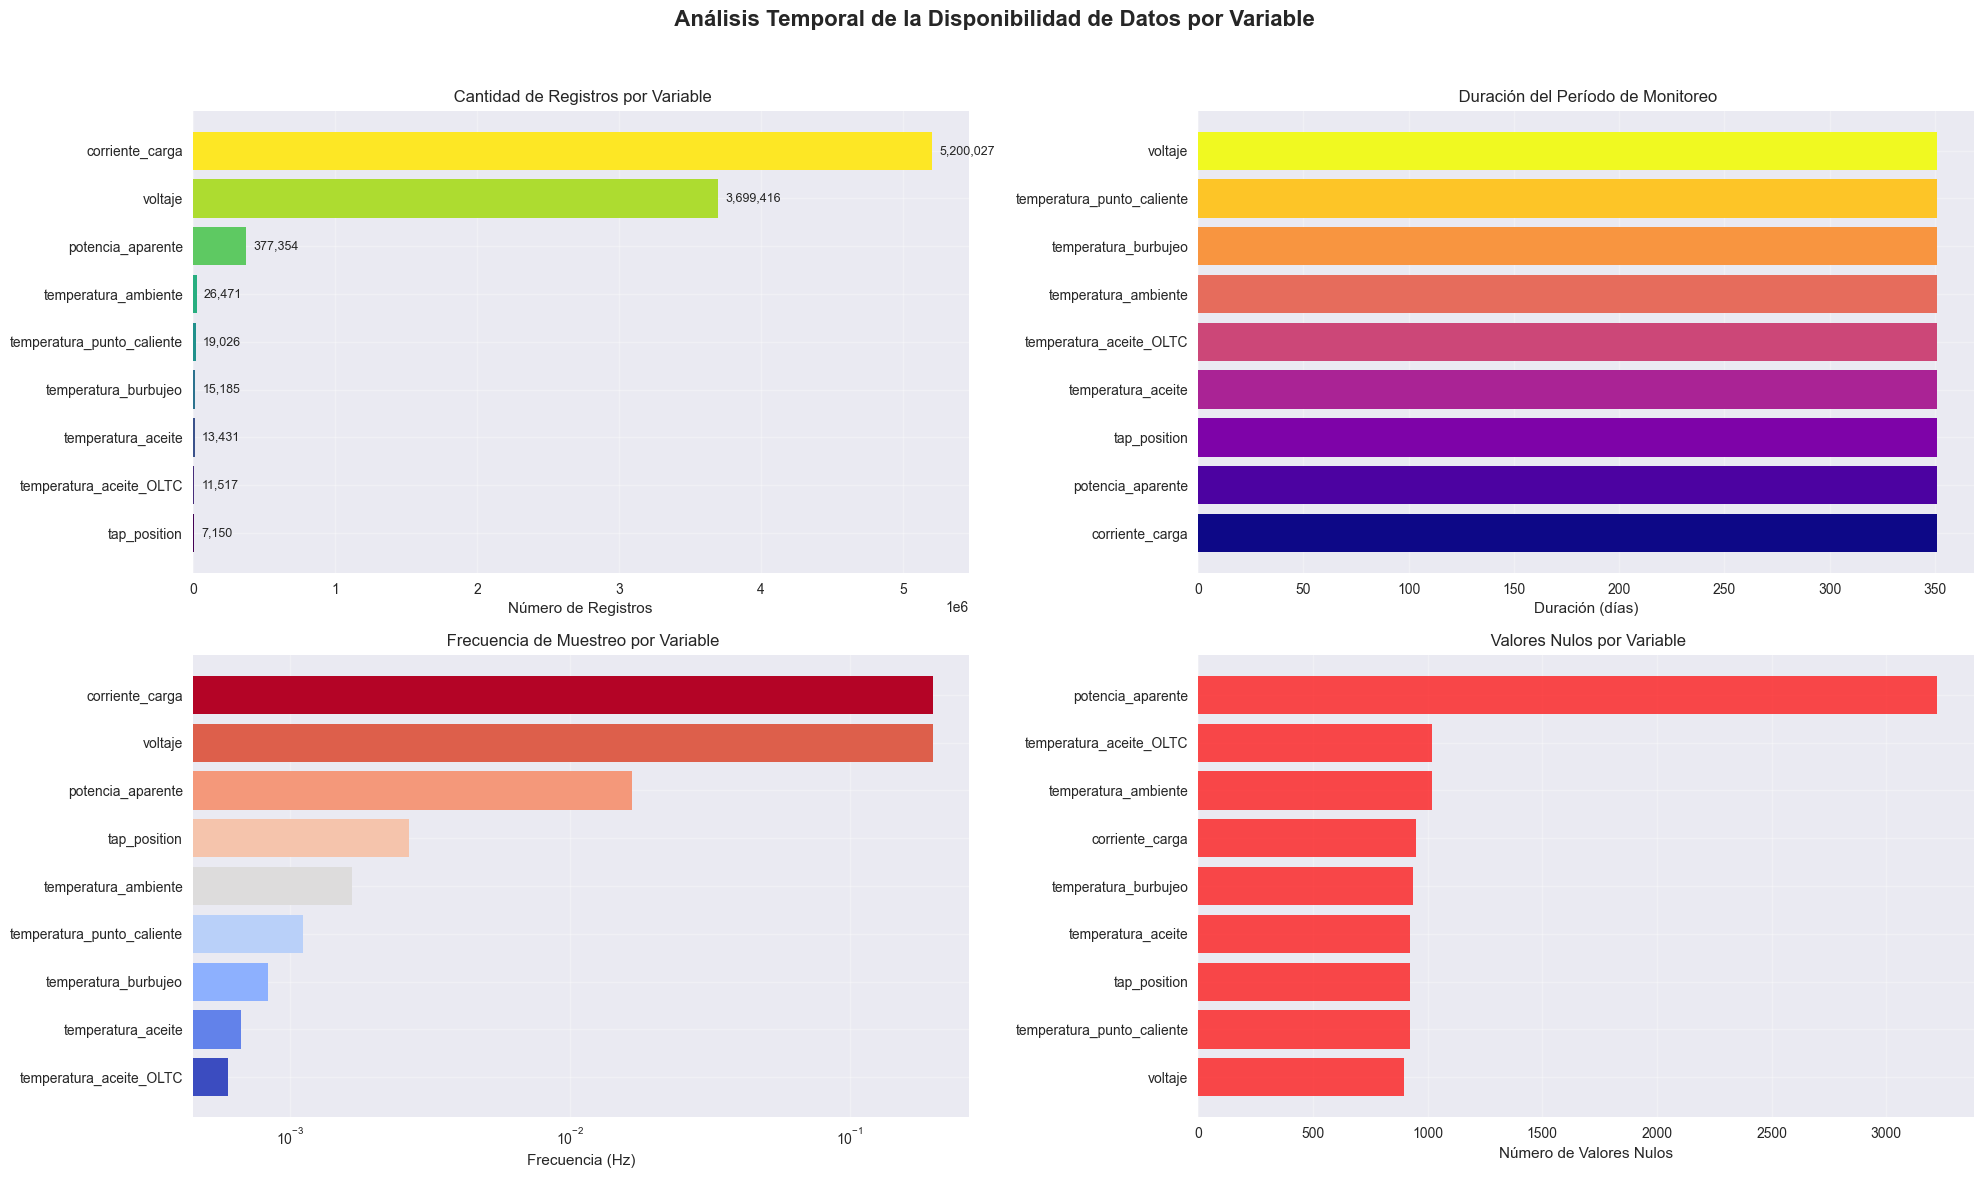


 TABLA DETALLADA DE FRECUENCIAS DE MUESTREO


,variable,intervalo_mediano_seg,intervalo_promedio_seg,intervalo_min_seg,intervalo_max_seg,desviacion_std_seg,freq_estimada_hz
0,corriente_carga,5.03,5.85,0.00,28800.00,36.69,0.198926
1,voltaje,5.04,8.22,0.01,28800.00,49.06,0.198334
2,potencia_aparente,60.00,80.56,60.00,16560.00,212.92,0.016667
3,tap_position,375.63,4252.63,0.07,28800.00,7978.01,0.002662
4,temperatura_ambiente,600.10,1148.92,0.00,28800.00,1474.98,0.001666
5,temperatura_punto_caliente,900.24,1598.50,0.01,28800.00,1900.10,0.001111
6,temperatura_burbujeo,1200.17,2002.77,0.00,28800.00,2436.45,0.000833
7,temperatura_aceite,1500.20,2264.61,0.00,28800.00,2505.75,0.000667
8,temperatura_aceite_OLTC,1666.70,2640.62,0.00,28800.00,3172.96,0.000600


In [7]:
# ==================== VISUALIZACIÓN: DISTRIBUCIÓN TEMPORAL Y FRECUENCIAS ====================
# Requisitos: resumen_df con columnas ['variable','registros','duracion_dias','valores_nulos']
#             freq_df con columnas ['variable','freq_estimada_hz', 'intervalo_*_seg']

print("Visualización de disponibilidad y frecuencia de muestreo")
print("=" * 70)

has_resumen = isinstance(resumen_df, pd.DataFrame) and not resumen_df.empty
has_freq    = isinstance(freq_df, pd.DataFrame) and not freq_df.empty

# Guard clauses
if has_resumen and has_freq:
    # --- Safe copies and column presence checks ---
    r = resumen_df.copy()
    f = freq_df.copy()

    # Ensure required columns exist
    required_r_cols = {"variable", "registros", "duracion_dias", "valores_nulos"}
    required_f_cols = {"variable", "freq_estimada_hz"}
    if not required_r_cols.issubset(r.columns) or not required_f_cols.issubset(f.columns):
        print("Faltan columnas requeridas para graficar.")
        print("   - resumen_df necesita:", required_r_cols)
        print("   - freq_df necesita:", required_f_cols)
    else:
        # --- Figure layout ---
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle(' Análisis Temporal de la Disponibilidad de Datos por Variable', fontsize=16, fontweight='bold')

        # ---------- Chart 1: Registros por variable ----------
        ax1 = axes[0, 0]
        registros_plot = r.sort_values('registros', ascending=True)
        bars = ax1.barh(registros_plot['variable'], registros_plot['registros'],
                        color=plt.cm.viridis(np.linspace(0, 1, len(registros_plot))))
        ax1.set_xlabel('Número de Registros')
        ax1.set_title(' Cantidad de Registros por Variable')
        ax1.grid(True, alpha=0.3)

        # Labels on bars
        max_reg = float(registros_plot['registros'].max()) if len(registros_plot) else 0.0
        for bar in bars:
            width = bar.get_width()
            ax1.text(width + (max_reg * 0.01 if max_reg > 0 else 0.1),
                     bar.get_y() + bar.get_height()/2,
                     f'{width:,.0f}', ha='left', va='center', fontsize=9)

        # ---------- Chart 2: Duración de monitoreo ----------
        ax2 = axes[0, 1]
        if 'duracion_dias' in r.columns:
            duracion_plot = r.sort_values('duracion_dias', ascending=True)
            bars2 = ax2.barh(duracion_plot['variable'], duracion_plot['duracion_dias'],
                             color=plt.cm.plasma(np.linspace(0, 1, len(duracion_plot))))
            ax2.set_xlabel('Duración (días)')
            ax2.set_title(' Duración del Período de Monitoreo')
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, "Columna 'duracion_dias' no disponible", ha='center', va='center')
            ax2.axis('off')

        # ---------- Chart 3: Frecuencia de muestreo ----------
        ax3 = axes[1, 0]
        # Keep only positive, finite frequencies for log-scale safety
        f_valid = f[np.isfinite(f['freq_estimada_hz']) & (f['freq_estimada_hz'] > 0)].copy()
        if not f_valid.empty:
            freq_plot = f_valid.sort_values('freq_estimada_hz', ascending=True)
            bars3 = ax3.barh(freq_plot['variable'], freq_plot['freq_estimada_hz'],
                             color=plt.cm.coolwarm(np.linspace(0, 1, len(freq_plot))))
            ax3.set_xlabel('Frecuencia (Hz)')
            ax3.set_title(' Frecuencia de Muestreo por Variable')
            ax3.set_xscale('log')
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, "Sin frecuencias > 0 para graficar en log-scale", ha='center', va='center')
            ax3.axis('off')

        # ---------- Chart 4: Valores nulos ----------
        ax4 = axes[1, 1]
        if 'valores_nulos' in r.columns:
            nulos_plot = r.sort_values('valores_nulos', ascending=True)
            colors = ['green' if x == 0 else 'red' for x in nulos_plot['valores_nulos']]
            bars4 = ax4.barh(nulos_plot['variable'], nulos_plot['valores_nulos'], color=colors, alpha=0.7)
            ax4.set_xlabel('Número de Valores Nulos')
            ax4.set_title(' Valores Nulos por Variable')
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, "Columna 'valores_nulos' no disponible", ha='center', va='center')
            ax4.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        # ---------- Styled table for frequencies ----------
        print("\n TABLA DETALLADA DE FRECUENCIAS DE MUESTREO")
        try:
            fmt_cols = {
                'intervalo_mediano_seg': '{:.2f}',
                'intervalo_promedio_seg': '{:.2f}',
                'intervalo_min_seg': '{:.2f}',
                'intervalo_max_seg': '{:.2f}',
                'desviacion_std_seg': '{:.2f}',
                'freq_estimada_hz': '{:.6f}',
            }
            # keep only columns that exist
            fmt_cols = {k: v for k, v in fmt_cols.items() if k in f.columns}

            styler = (f.style
                        .format(fmt_cols, na_rep="—")
                        .background_gradient(subset=[c for c in ['freq_estimada_hz'] if c in f.columns], cmap='RdYlGn')
                        .set_caption("Análisis Detallado de Frecuencias de Muestreo"))
            display(styler)
        except Exception:
            print("Análisis Detallado de Frecuencias de Muestreo (fallback)")
            print("-" * 120)
            display(f)

else:
    print("  No se pueden generar visualizaciones - faltan datos")
    if not has_resumen:
        print("    No hay datos de resumen cargados (resumen_df vacío)")
    if not has_freq:
        print("    No hay datos de frecuencia calculados (freq_df vacío)")

    # Diagnóstico
    n_series = len(datos_por_tag) if isinstance(datos_por_tag, dict) else 0
    print("\n DIAGNÓSTICO:")
    print(f"    Variables en datos_por_tag: {n_series}")
    print(f"    Filas en resumen_df: {len(resumen_df) if has_resumen else 0}")
    print(f"   Filas en freq_df: {len(freq_df) if has_freq else 0}")
    print("    Asegúrate de haber corrido la carga desde Bronze y el cálculo de frecuencias.")


# Evaluación de Calidad y Completitud de Datos

La evaluación de la calidad de datos constituye un aspecto fundamental en el análisis de sistemas de monitoreo industrial, especialmente crítico cuando se trata de desarrollar sistemas de mantenimiento predictivo. La calidad de los datos puede verse comprometida por múltiples factores incluyendo fallos de sensores, interrupciones de comunicación, problemas de sincronización temporal, y errores de calibración.

In [ ]:
# ==================== EVALUACIÓN COMPRENSIVA DE CALIDAD DE DATOS (adaptado) ====================

def evaluar_calidad_datos(datos_dict: dict[str, pd.DataFrame],
                          max_gap: pd.Timedelta = pd.Timedelta(hours=1)) -> pd.DataFrame:
    """
    Run an exhaustive, defensive data quality check per variable.
    
    Parameters
    ----------
    datos_dict : dict[str, pd.DataFrame]
        Mapping '<variable>' -> DataFrame with columns ['timestamp', '<variable>'].
    max_gap : pd.Timedelta
        Threshold to count significant temporal gaps.

    Returns
    -------
    pd.DataFrame
        One row per variable with quality metrics.
    """
    if not isinstance(datos_dict, dict) or len(datos_dict) == 0:
        print("  No hay datos para evaluar calidad")
        return pd.DataFrame()

    metricas_calidad: list[dict] = []

    for variable, df in datos_dict.items():
        # --- Defensive guards ---
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            continue
        if "timestamp" not in df.columns:
            continue

        # Identify value column (any column != 'timestamp')
        value_cols = [c for c in df.columns if c != "timestamp"]
        if not value_cols:
            continue
        col_valor = value_cols[0]

        # Ensure timestamp is datetime, sorted, and drop NaT
        tmp = df[["timestamp", col_valor]].copy()
        tmp["timestamp"] = pd.to_datetime(tmp["timestamp"], errors="coerce", utc=True)
        tmp = tmp.dropna(subset=["timestamp"]).sort_values("timestamp")

        # Convert values to numeric when possible
        s_val = pd.to_numeric(tmp[col_valor], errors="coerce")

        # completitud basica
        total_registros = int(len(tmp))
        valores_nulos = int(s_val.isna().sum())
        valores_validos = int(total_registros - valores_nulos)
        porcentaje_completitud = (valores_validos / total_registros) * 100 if total_registros > 0 else 0.0

        # Duplicates
        timestamps_duplicados = int(tmp["timestamp"].duplicated().sum())
        registros_completamente_duplicados = int(tmp.duplicated().sum())

        # Extremes and sign checks (on numeric values only)
        valores_infinitos = int(np.isinf(s_val).sum())
        valores_cero = int((s_val == 0).sum(skipna=True)) if valores_validos > 0 else 0
        valores_negativos = int((s_val < 0).sum(skipna=True)) if valores_validos > 0 else 0

        # Temporal consistency
        diffs = tmp["timestamp"].diff().dropna()
        gaps_significativos = int((diffs > max_gap).sum())

        # Range and dispersion
        vmin = float(s_val.min(skipna=True)) if valores_validos > 0 else np.nan
        vmax = float(s_val.max(skipna=True)) if valores_validos > 0 else np.nan
        rango_valores = (vmax - vmin) if (pd.notna(vmax) and pd.notna(vmin)) else np.nan

        mean_val = float(s_val.mean(skipna=True)) if valores_validos > 0 else np.nan
        std_val = float(s_val.std(skipna=True)) if valores_validos > 1 else np.nan
        coef_variacion = (std_val / mean_val) if (pd.notna(std_val) and pd.notna(mean_val) and mean_val != 0) else np.inf

        # Diversity / constant signal detection
        valores_unicos = int(s_val.nunique(dropna=True)) if valores_validos > 0 else 0
        porcentaje_valores_unicos = (valores_unicos / valores_validos) * 100 if valores_validos > 0 else 0.0

        # Outliers via IQR (only on valid numeric values)
        sv = s_val.dropna()
        if len(sv) >= 4:  # need enough points for quartiles
            Q1 = float(sv.quantile(0.25))
            Q3 = float(sv.quantile(0.75))
            IQR = Q3 - Q1
            lo, hi = (Q1 - 1.5 * IQR), (Q3 + 1.5 * IQR)
            outliers_iqr = int(((sv < lo) | (sv > hi)).sum())
            porcentaje_outliers = (outliers_iqr / len(sv)) * 100 if len(sv) > 0 else 0.0
        else:
            outliers_iqr = 0
            porcentaje_outliers = 0.0

        metricas = {
            "variable": variable,
            "total_registros": total_registros,
            "valores_validos": valores_validos,
            "valores_nulos": valores_nulos,
            "porcentaje_completitud": porcentaje_completitud,
            "timestamps_duplicados": timestamps_duplicados,
            "registros_duplicados": registros_completamente_duplicados,
            "valores_infinitos": valores_infinitos,
            "valores_cero": valores_cero,
            "valores_negativos": valores_negativos,
            "gaps_temporales_significativos": gaps_significativos,
            "rango_valores": rango_valores,
            "coeficiente_variacion": coef_variacion,
            "valores_unicos": valores_unicos,
            "porcentaje_diversidad": porcentaje_valores_unicos,
            "outliers_iqr": outliers_iqr,
            "porcentaje_outliers": porcentaje_outliers
        }
        metricas_calidad.append(metricas)

    return pd.DataFrame(metricas_calidad)


# ---------- Ejecutar evaluación (usa datos_por_tag) ----------
if isinstance(datos_por_tag, dict) and len(datos_por_tag) > 0:
    print(" Evaluando calidad de datos...")
    calidad_datos = evaluar_calidad_datos(datos_por_tag, max_gap=pd.Timedelta(hours=1))
    print("* Evaluación de calidad completada")
    print(f"* Variables analizadas: {len(calidad_datos)}")
else:
    print(" No se puede evaluar calidad — no hay datos cargados en 'datos_por_tag'")
    calidad_datos = pd.DataFrame()


 Evaluando calidad de datos...
* Evaluación de calidad completada
* Variables analizadas: 9


In [9]:
# ==================== REPORTE DETALLADO DE CALIDAD DE DATOS (adaptado) ====================

print(" REPORTE DETALLADO DE CALIDAD DE DATOS")
print("=" * 100)

has_quality = isinstance(calidad_datos, pd.DataFrame) and not calidad_datos.empty

if has_quality:
    # --- Choose only columns that actually exist (defensive) ---
    desired_cols = [
        'variable', 'total_registros', 'porcentaje_completitud',
        'timestamps_duplicados', 'registros_duplicados', 'gaps_temporales_significativos',
        'valores_unicos', 'porcentaje_diversidad', 'porcentaje_outliers'
    ]
    view_cols = [c for c in desired_cols if c in calidad_datos.columns]
    quality_view = calidad_datos[view_cols].copy()

    # --- Pretty Styler with safe column subsets ---
    try:
        fmt_map = {}
        if 'total_registros' in quality_view.columns: fmt_map['total_registros'] = '{:,}'
        if 'porcentaje_completitud' in quality_view.columns: fmt_map['porcentaje_completitud'] = '{:.2f}%'
        if 'timestamps_duplicados' in quality_view.columns: fmt_map['timestamps_duplicados'] = '{:,}'
        if 'registros_duplicados' in quality_view.columns: fmt_map['registros_duplicados'] = '{:,}'
        if 'gaps_temporales_significativos' in quality_view.columns: fmt_map['gaps_temporales_significativos'] = '{:,}'
        if 'valores_unicos' in quality_view.columns: fmt_map['valores_unicos'] = '{:,}'
        if 'porcentaje_diversidad' in quality_view.columns: fmt_map['porcentaje_diversidad'] = '{:.2f}%'
        if 'porcentaje_outliers' in quality_view.columns: fmt_map['porcentaje_outliers'] = '{:.2f}%'

        styler = (quality_view.style
                  .format(fmt_map, na_rep="—")
                  .set_caption("Métricas Principales de Calidad de Datos"))

        # Color maps applied only if those columns are present
        if 'porcentaje_completitud' in quality_view.columns:
            styler = styler.background_gradient(subset=['porcentaje_completitud'], cmap='RdYlGn', vmin=80, vmax=100)
        if 'porcentaje_outliers' in quality_view.columns:
            styler = styler.background_gradient(subset=['porcentaje_outliers'], cmap='RdYlBu_r', vmin=0, vmax=10)

        display(styler)
    except Exception:
        print("Métricas Principales de Calidad de Datos (fallback)")
        print("-" * 100)
        display(quality_view)

    # ------------------ Issue detection & reporting ------------------
    print("\n*  IDENTIFICACIÓN DE PROBLEMAS DE CALIDAD  *")
    print("-" * 60)

    # Helper getters to avoid KeyError
    def col(name: str) -> pd.Series:
        return calidad_datos[name] if name in calidad_datos.columns else pd.Series(dtype=float)

    # 1) Completeness
    if 'porcentaje_completitud' in calidad_datos.columns:
        variables_incomplete = calidad_datos[calidad_datos['porcentaje_completitud'] < 100]
        if len(variables_incomplete) > 0:
            print(f"1. Variables con datos faltantes ({len(variables_incomplete)}):")
            for _, row in variables_incomplete.iterrows():
                var = row.get('variable', 'N/D')
                nulos = int(row.get('valores_nulos', 0))
                pct_missing = 100 - float(row.get('porcentaje_completitud', 100.0))
                print(f"   • {var}: {nulos:,} nulos ({pct_missing:.2f}% faltante)")
        else:
            print(" Todas las variables tienen datos completos (100% completitud)")
    else:
        print(" Métrica 'porcentaje_completitud' no disponible.")

    # 2) Duplicates
    if ('timestamps_duplicados' in calidad_datos.columns) or ('registros_duplicados' in calidad_datos.columns):
        cond = pd.Series(False, index=calidad_datos.index)
        if 'timestamps_duplicados' in calidad_datos.columns:
            cond = cond | (calidad_datos['timestamps_duplicados'] > 0)
        if 'registros_duplicados' in calidad_datos.columns:
            cond = cond | (calidad_datos['registros_duplicados'] > 0)

        variables_duplicadas = calidad_datos[cond]
        if len(variables_duplicadas) > 0:
            print(f"\n2. Variables con duplicaciones ({len(variables_duplicadas)}):")
            for _, row in variables_duplicadas.iterrows():
                var = row.get('variable', 'N/D')
                ts_dup = int(row.get('timestamps_duplicados', 0))
                rec_dup = int(row.get('registros_duplicados', 0))
                if ts_dup > 0:
                    print(f"   • {var}: {ts_dup:,} timestamps duplicados")
                if rec_dup > 0:
                    print(f"   • {var}: {rec_dup:,} registros completamente duplicados")
        else:
            print("\n No se encontraron duplicaciones en ninguna variable")
    else:
        print("\n  Métricas de duplicación no disponibles.")

    # 3) Temporal continuity (gaps)
    if 'gaps_temporales_significativos' in calidad_datos.columns:
        variables_gaps = calidad_datos[calidad_datos['gaps_temporales_significativos'] > 0]
        if len(variables_gaps) > 0:
            print(f"\n3. Variables con gaps temporales significativos ({len(variables_gaps)}):")
            for _, row in variables_gaps.iterrows():
                var = row.get('variable', 'N/D')
                gaps = int(row.get('gaps_temporales_significativos', 0))
                print(f"   • {var}: {gaps:,} gaps >1 hora")
        else:
            print("\n Continuidad temporal adecuada en todas las variables")
    else:
        print("\n Metrica 'gaps_temporales_significativos' no disponible.")

    # 4) Low diversity / stuck sensors
    if 'porcentaje_diversidad' in calidad_datos.columns:
        variables_baja_diversidad = calidad_datos[calidad_datos['porcentaje_diversidad'] < 10]
        if len(variables_baja_diversidad) > 0:
            print(f"\n4. Variables con baja diversidad de valores (<10%) ({len(variables_baja_diversidad)}):")
            for _, row in variables_baja_diversidad.iterrows():
                var = row.get('variable', 'N/D')
                pct_div = float(row.get('porcentaje_diversidad', 0.0))
                vuni = int(row.get('valores_unicos', 0))
                print(f"   • {var}: {pct_div:.2f}% diversidad ({vuni:,} valores únicos)")
        else:
            print("\n Todas las variables muestran diversidad adecuada de valores")
    else:
        print("\n Metrica 'porcentaje_diversidad' no disponible.")

    # 5) Outliers share
    if 'porcentaje_outliers' in calidad_datos.columns:
        variables_muchos_outliers = calidad_datos[calidad_datos['porcentaje_outliers'] > 5]
        if len(variables_muchos_outliers) > 0:
            print(f"\n5. Variables con alta proporción de outliers (>5%) ({len(variables_muchos_outliers)}):")
            for _, row in variables_muchos_outliers.iterrows():
                var = row.get('variable', 'N/D')
                pct_out = float(row.get('porcentaje_outliers', 0.0))
                n_out = int(row.get('outliers_iqr', 0))
                print(f"   • {var}: {pct_out:.2f}% outliers ({n_out:,} valores)")
        else:
            print("\n Proporción de outliers dentro de rangos aceptables (<5%)")
    else:
        print("\n Metrica 'porcentaje_outliers' no disponible.")

else:
    print(" No se puede generar reporte de calidad - no hay datos para analizar")
    print(" Los datos no se pudieron cargar correctamente")

    # Empty placeholders to avoid later-cell errors
    variables_incomplete = pd.DataFrame()
    variables_duplicadas = pd.DataFrame()
    variables_gaps = pd.DataFrame()
    variables_baja_diversidad = pd.DataFrame()
    variables_muchos_outliers = pd.DataFrame()


 REPORTE DETALLADO DE CALIDAD DE DATOS


,variable,total_registros,porcentaje_completitud,timestamps_duplicados,registros_duplicados,gaps_temporales_significativos,valores_unicos,porcentaje_diversidad,porcentaje_outliers
0,temperatura_aceite,"13,431",93.13%,2,0,"2,846",388,3.10%,0.02%
1,temperatura_aceite_OLTC,"11,517",91.15%,2,0,"3,117",363,3.46%,0.02%
2,temperatura_ambiente,"26,471",96.16%,3,0,"1,665",375,1.47%,0.41%
3,temperatura_burbujeo,"15,185",93.84%,1,0,"2,672",386,2.71%,0.01%
4,temperatura_punto_caliente,"19,026",95.15%,1,0,"2,050","17,163",94.80%,0.01%
5,voltaje,"3,699,416",99.98%,1,0,17,"895,288",24.21%,1.20%
6,corriente_carga,"5,200,027",99.98%,1,0,19,"4,171,425",80.23%,5.22%
7,potencia_aparente,"377,354",99.15%,0,0,265,"371,088",99.19%,1.23%
8,tap_position,"7,150",87.09%,1,0,"1,825",18,0.29%,1.75%



*  IDENTIFICACIÓN DE PROBLEMAS DE CALIDAD  *
------------------------------------------------------------
1. Variables con datos faltantes (9):
   • temperatura_aceite: 923 nulos (6.87% faltante)
   • temperatura_aceite_OLTC: 1,019 nulos (8.85% faltante)
   • temperatura_ambiente: 1,017 nulos (3.84% faltante)
   • temperatura_burbujeo: 936 nulos (6.16% faltante)
   • temperatura_punto_caliente: 922 nulos (4.85% faltante)
   • voltaje: 896 nulos (0.02% faltante)
   • corriente_carga: 951 nulos (0.02% faltante)
   • potencia_aparente: 3,221 nulos (0.85% faltante)
   • tap_position: 923 nulos (12.91% faltante)

2. Variables con duplicaciones (8):
   • temperatura_aceite: 2 timestamps duplicados
   • temperatura_aceite_OLTC: 2 timestamps duplicados
   • temperatura_ambiente: 3 timestamps duplicados
   • temperatura_burbujeo: 1 timestamps duplicados
   • temperatura_punto_caliente: 1 timestamps duplicados
   • voltaje: 1 timestamps duplicados
   • corriente_carga: 1 timestamps duplicados
 

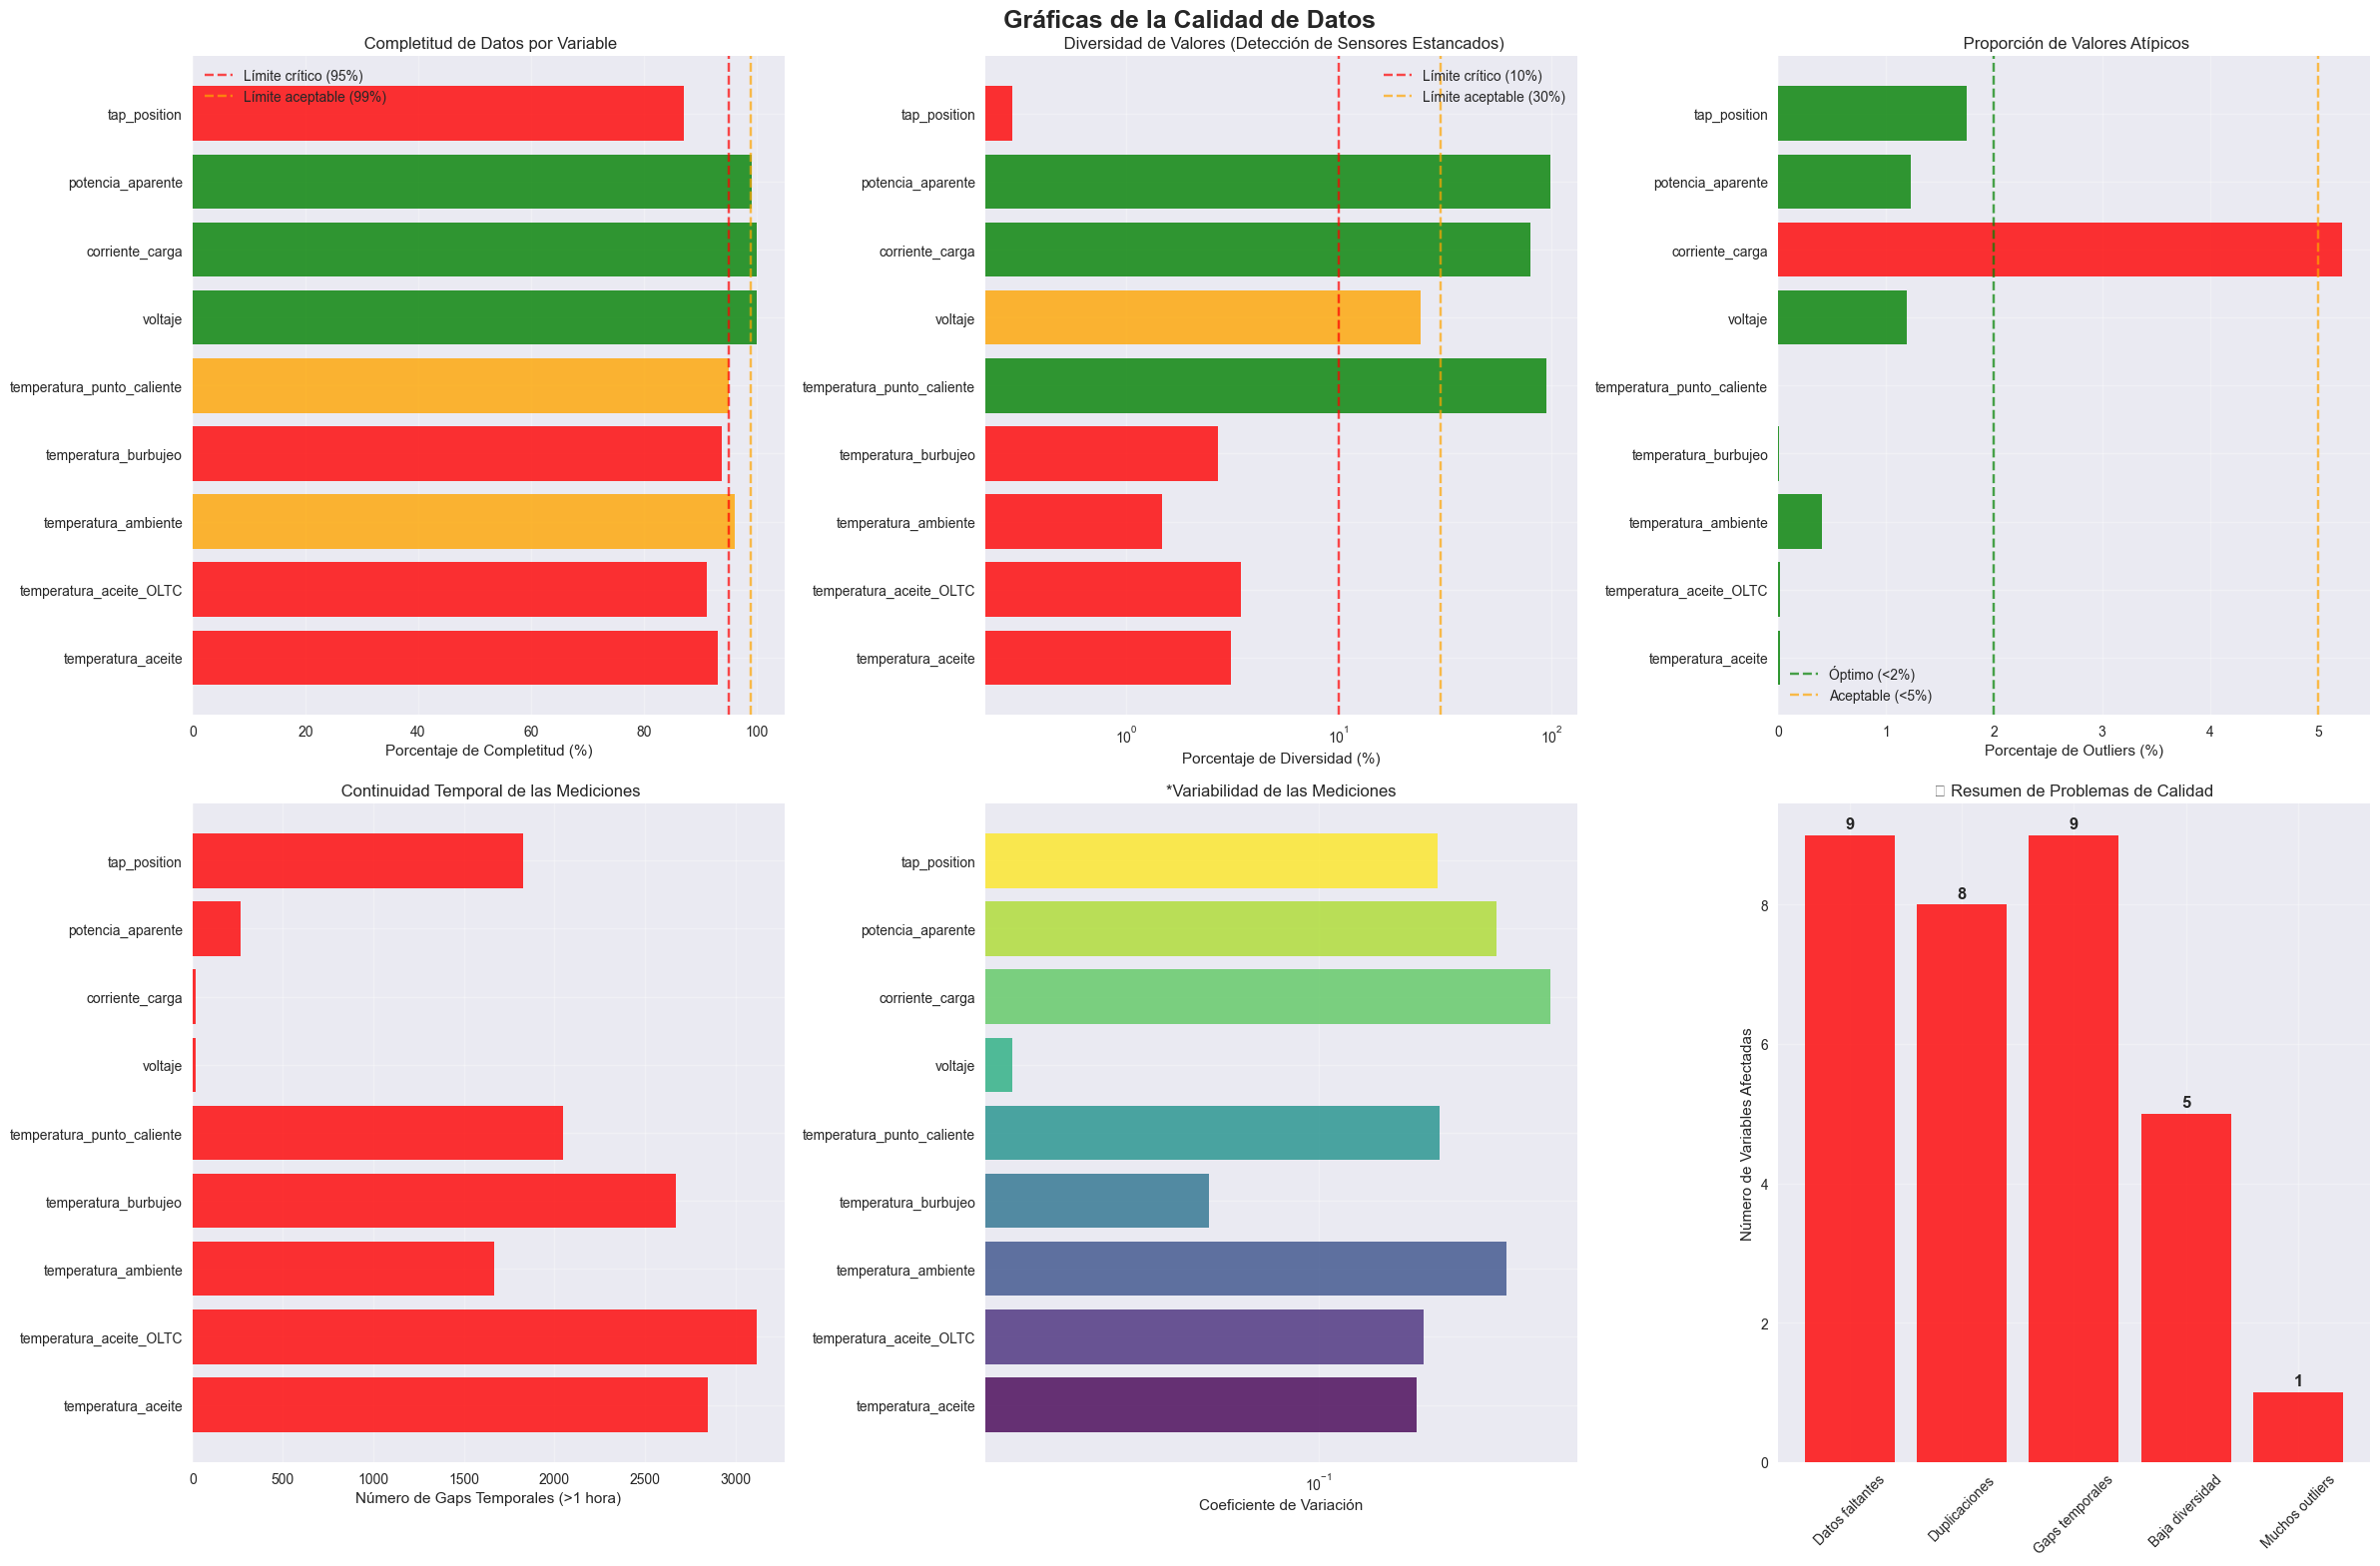

In [ ]:
# ==================== DASHBOARD DE CALIDAD DE DATOS (adaptado) ====================

has_quality = isinstance(calidad_datos, pd.DataFrame) and not calidad_datos.empty

if has_quality:
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    fig.suptitle('Gráficas de la Calidad de Datos', fontsize=18, fontweight='bold')

    # ---------- Helpers ----------
    def col_exists(*names: str) -> bool:
        return all(n in calidad_datos.columns for n in names)

    def safe_series(name: str):
        return calidad_datos[name] if name in calidad_datos.columns else pd.Series([np.nan] * len(calidad_datos))

    # ---------- Chart 1: Completitud ----------
    ax1 = axes[0, 0]
    if col_exists('variable', 'porcentaje_completitud'):
        s = safe_series('porcentaje_completitud').fillna(0)
        colors = ['green' if x >= 99 else 'orange' if x >= 95 else 'red' for x in s]
        ax1.barh(safe_series('variable'), s, color=colors, alpha=0.8)
        ax1.set_xlabel('Porcentaje de Completitud (%)')
        ax1.set_title(' Completitud de Datos por Variable')
        ax1.axvline(x=95, color='red', linestyle='--', alpha=0.7, label='Límite crítico (95%)')
        ax1.axvline(x=99, color='orange', linestyle='--', alpha=0.7, label='Límite aceptable (99%)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, "Columnas necesarias no disponibles:\n'porcentaje_completitud'", ha='center', va='center')
        ax1.axis('off')

    # ---------- Chart 2: Diversidad ----------
    ax2 = axes[0, 1]
    if col_exists('variable', 'porcentaje_diversidad'):
        s = safe_series('porcentaje_diversidad').fillna(0)
        colors = ['red' if x < 10 else 'orange' if x < 30 else 'green' for x in s]
        ax2.barh(safe_series('variable'), s, color=colors, alpha=0.8)
        ax2.set_xlabel('Porcentaje de Diversidad (%)')
        ax2.set_title(' Diversidad de Valores (Detección de Sensores Estancados)')
        ax2.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Límite crítico (10%)')
        ax2.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='Límite aceptable (30%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        # Use log scale only if all values are > 0
        if (s > 0).all():
            ax2.set_xscale('log')
    else:
        ax2.text(0.5, 0.5, "Columnas necesarias no disponibles:\n'porcentaje_diversidad'", ha='center', va='center')
        ax2.axis('off')

    # ---------- Chart 3: Outliers ----------
    ax3 = axes[0, 2]
    if col_exists('variable', 'porcentaje_outliers'):
        s = safe_series('porcentaje_outliers').fillna(0)
        colors = ['green' if x <= 2 else 'orange' if x <= 5 else 'red' for x in s]
        ax3.barh(safe_series('variable'), s, color=colors, alpha=0.8)
        ax3.set_xlabel('Porcentaje de Outliers (%)')
        ax3.set_title(' Proporción de Valores Atípicos')
        ax3.axvline(x=2, color='green', linestyle='--', alpha=0.7, label='Óptimo (<2%)')
        ax3.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Aceptable (<5%)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, "Columnas necesarias no disponibles:\n'porcentaje_outliers'", ha='center', va='center')
        ax3.axis('off')

    # ---------- Chart 4: Gaps temporales ----------
    ax4 = axes[1, 0]
    if col_exists('variable', 'gaps_temporales_significativos'):
        s = safe_series('gaps_temporales_significativos').fillna(0)
        colors = ['green' if x == 0 else 'orange' if x <= 10 else 'red' for x in s]
        ax4.barh(safe_series('variable'), s, color=colors, alpha=0.8)
        ax4.set_xlabel('Número de Gaps Temporales (>1 hora)')
        ax4.set_title(' Continuidad Temporal de las Mediciones')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, "Columnas necesarias no disponibles:\n'gaps_temporales_significativos'", ha='center', va='center')
        ax4.axis('off')

    # ---------- Chart 5: Coeficiente de variación ----------
    ax5 = axes[1, 1]
    if col_exists('variable', 'coeficiente_variacion'):
        coef_var = safe_series('coeficiente_variacion').replace([np.inf, -np.inf], np.nan)
        mask = coef_var.notna()
        if mask.any():
            ax5.barh(safe_series('variable')[mask], coef_var[mask],
                     color=plt.cm.viridis(np.linspace(0, 1, int(mask.sum()))), alpha=0.8)
            # Log-scale only if all positive
            if (coef_var[mask] > 0).all():
                ax5.set_xscale('log')
        ax5.set_xlabel('Coeficiente de Variación')
        ax5.set_title('*Variabilidad de las Mediciones')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, "Columna no disponible:\n'coeficiente_variacion'", ha='center', va='center')
        ax5.axis('off')

    # ---------- Chart 6: Resumen de problemas ----------
    ax6 = axes[1, 2]
    # Build issue subsets safely
    variables_incomplete = calidad_datos[calidad_datos['porcentaje_completitud'] < 100] \
        if 'porcentaje_completitud' in calidad_datos.columns else pd.DataFrame()
    variables_duplicadas = calidad_datos[
        ((calidad_datos['timestamps_duplicados'] > 0) if 'timestamps_duplicados' in calidad_datos.columns else False) |
        ((calidad_datos['registros_duplicados'] > 0) if 'registros_duplicados' in calidad_datos.columns else False)
    ] if ('timestamps_duplicados' in calidad_datos.columns or 'registros_duplicados' in calidad_datos.columns) else pd.DataFrame()
    variables_gaps = calidad_datos[calidad_datos['gaps_temporales_significativos'] > 0] \
        if 'gaps_temporales_significativos' in calidad_datos.columns else pd.DataFrame()
    variables_baja_diversidad = calidad_datos[calidad_datos['porcentaje_diversidad'] < 10] \
        if 'porcentaje_diversidad' in calidad_datos.columns else pd.DataFrame()
    variables_muchos_outliers = calidad_datos[calidad_datos['porcentaje_outliers'] > 5] \
        if 'porcentaje_outliers' in calidad_datos.columns else pd.DataFrame()

    problemas = {
        'Datos faltantes': len(variables_incomplete),
        'Duplicaciones': len(variables_duplicadas),
        'Gaps temporales': len(variables_gaps),
        'Baja diversidad': len(variables_baja_diversidad),
        'Muchos outliers': len(variables_muchos_outliers)
    }
    colores_problemas = ['red' if v > 0 else 'green' for v in problemas.values()]
    bars6 = ax6.bar(list(problemas.keys()), list(problemas.values()), color=colores_problemas, alpha=0.8)
    ax6.set_ylabel('Número de Variables Afectadas')
    ax6.set_title(' Resumen de Problemas de Calidad')
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(True, alpha=0.3)

    for bar, valor in zip(bars6, problemas.values()):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(valor),
                 ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("No se pueden generar visualizaciones de calidad - no hay datos para analizar")
    # Si tienes BRONZE_TABLE definido, muestra pista de ruta
    try:
        print("Verifica la tabla Delta (Bronze) en:")
        print(f" Ruta esperada: {Path(BRONZE_TABLE).absolute()}")
    except Exception:
        pass

    # Mensaje gráfico simple
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.text(0.5, 0.5, ' No hay datos para visualizar\n\n Verifique la carga desde Bronze\n Ejecute las celdas previas',
            ha='center', va='center', fontsize=16,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title('Dashboard de Calidad de Datos - Sin datos', fontsize=18, fontweight='bold')
    ax.axis('off')
    plt.show()
